In [1]:
import pandas as pd

# -----------------------------------------
# Load the dataset
# -----------------------------------------
df = pd.read_csv("student_data.csv")

# -----------------------------------------
# 1. Print first 5 rows
# -----------------------------------------
print("=== 1. FIRST 5 ROWS ===")
print(df.head())


# -----------------------------------------
# 2. Print shape and data types
# -----------------------------------------
print("\n=== 2. SHAPE AND DATA TYPES ===")
print("Shape (rows, columns):", df.shape)
print("\nData types:")
print(df.dtypes)


# -----------------------------------------
# 3. Summary statistics for numeric columns
# -----------------------------------------
print("\n=== 3. SUMMARY STATISTICS ===")
print(df.describe())


# -----------------------------------------
# 4. Count of students who passed and failed
# -----------------------------------------
print("\n=== 4. PASS / FAIL COUNTS ===")
print(df['passed'].value_counts())


# -----------------------------------------
# 5. Average subject scores for passing vs failing students
# -----------------------------------------
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\n=== 5. AVERAGE SCORES FOR PASSING STUDENTS ===")
print(df[df['passed'] == 1][subject_cols].mean())

print("\n=== 5. AVERAGE SCORES FOR FAILING STUDENTS ===")
print(df[df['passed'] == 0][subject_cols].mean())


# -----------------------------------------
# 6. Student with highest overall average
# -----------------------------------------
df['overall_avg'] = df[subject_cols].mean(axis=1)

top_student = df.loc[df['overall_avg'].idxmax()]

print("\n=== 6. STUDENT WITH HIGHEST OVERALL AVERAGE ===")
print(top_student)


=== 1. FIRST 5 ROWS ===
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

=== 2. SHAPE AND DATA TYPES ===
Shape (rows, columns): (15, 9)

Data types:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

=== 

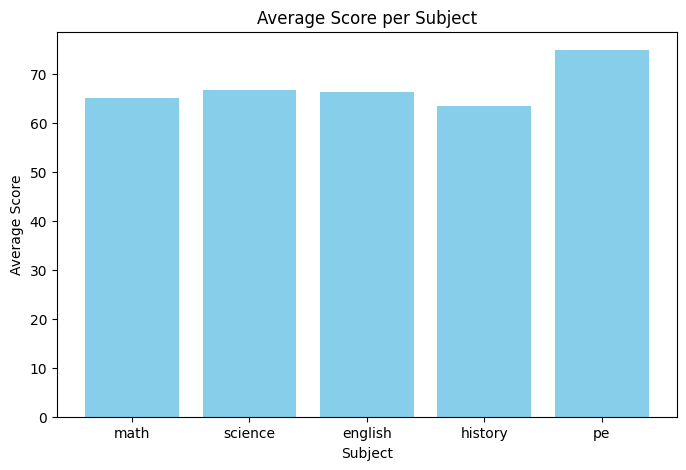

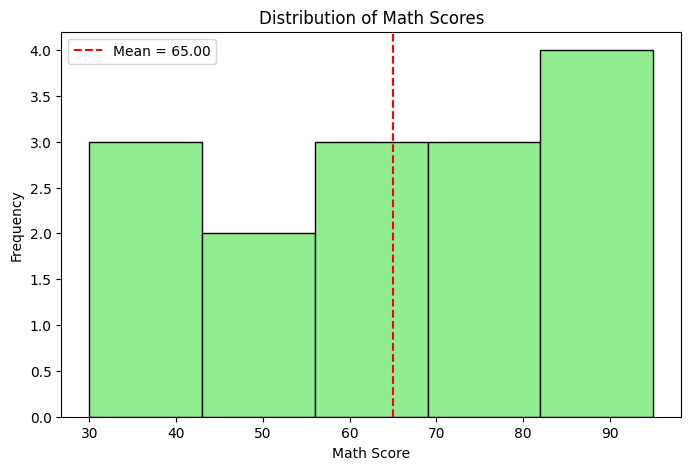

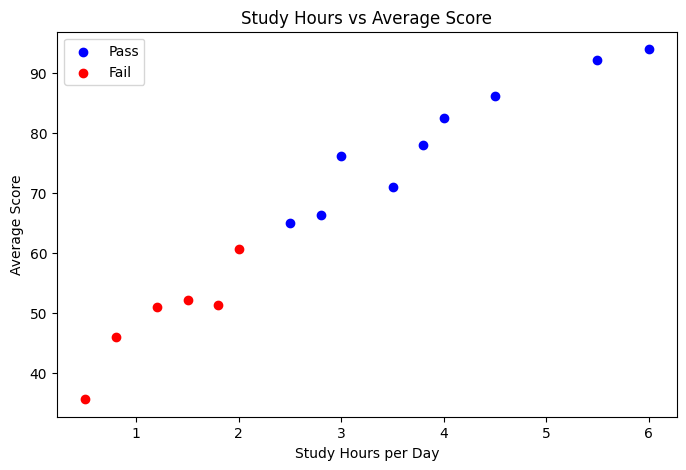

C:\Users\User\AppData\Local\Temp\ipykernel_8000\1973806462.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance],


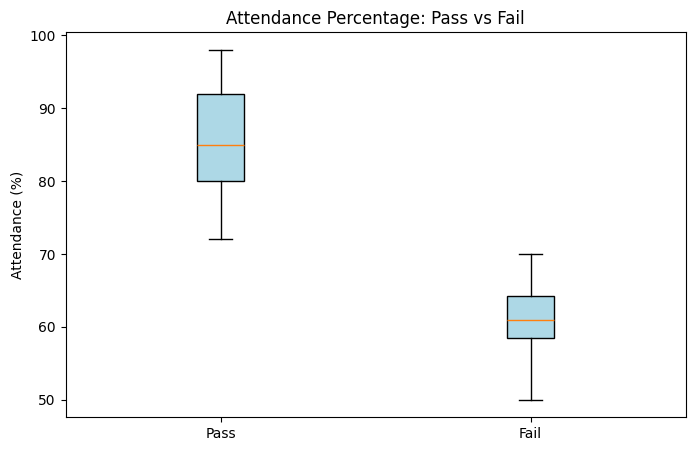

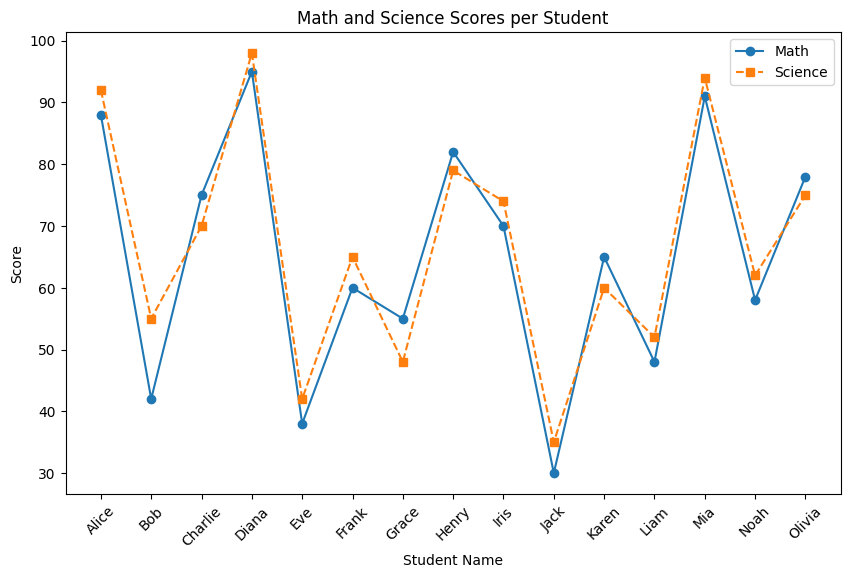

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------
# Load dataset
# -----------------------------------------
df = pd.read_csv("student_data.csv")

# Add avg_score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# -----------------------------------------
# 1. BAR CHART — Average score per subject
# -----------------------------------------
plt.figure(figsize=(8,5))
avg_per_subject = df[subject_cols].mean()

plt.bar(subject_cols, avg_per_subject, color='skyblue')
plt.title("Average Score per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")

plt.savefig("plot1_bar.png")
plt.show()


# -----------------------------------------
# 2. HISTOGRAM — Math score distribution
# -----------------------------------------
plt.figure(figsize=(8,5))
plt.hist(df['math'], bins=5, color='lightgreen', edgecolor='black')

mean_math = df['math'].mean()
plt.axvline(mean_math, color='red', linestyle='--', label=f"Mean = {mean_math:.2f}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("plot2_histogram.png")
plt.show()


# -----------------------------------------
# 3. SCATTER PLOT — Study hours vs avg_score
# -----------------------------------------
plt.figure(figsize=(8,5))

pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'],
            color='blue', label='Pass')

plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'],
            color='red', label='Fail')

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()


# -----------------------------------------
# 4. BOX PLOT — Attendance for Pass vs Fail
# -----------------------------------------
plt.figure(figsize=(8,5))

pass_attendance = pass_df['attendance_pct'].tolist()
fail_attendance = fail_df['attendance_pct'].tolist()

plt.boxplot([pass_attendance, fail_attendance],
            labels=['Pass', 'Fail'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue'))

plt.title("Attendance Percentage: Pass vs Fail")
plt.ylabel("Attendance (%)")

plt.savefig("plot4_boxplot.png")
plt.show()


# -----------------------------------------
# 5. LINE PLOT — Math vs Science per student
# -----------------------------------------
plt.figure(figsize=(10,6))

plt.plot(df['name'], df['math'], marker='o', linestyle='-', label='Math')
plt.plot(df['name'], df['science'], marker='s', linestyle='--', label='Science')

plt.title("Math and Science Scores per Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()

plt.savefig("plot5_lineplot.png")
plt.show()


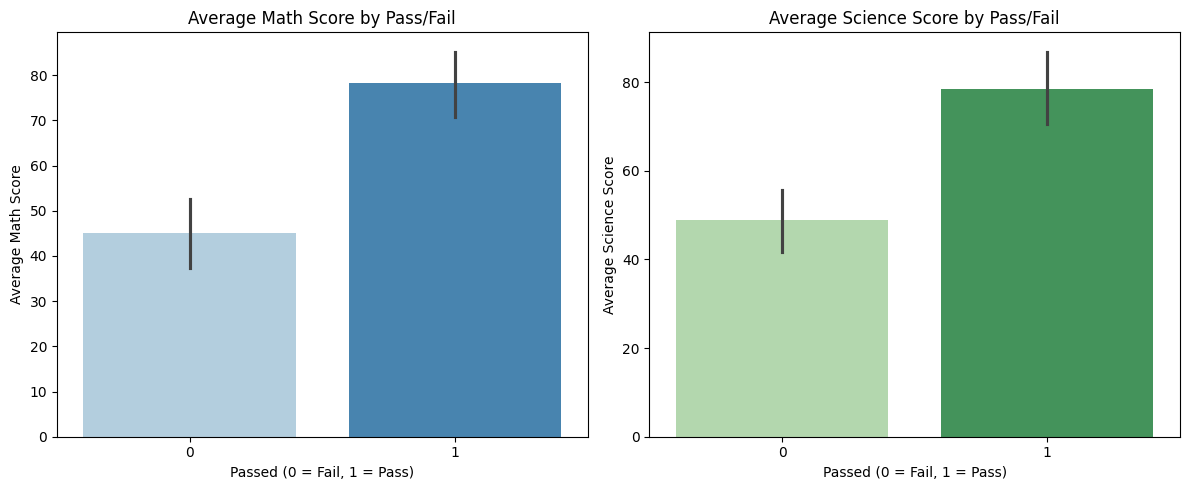

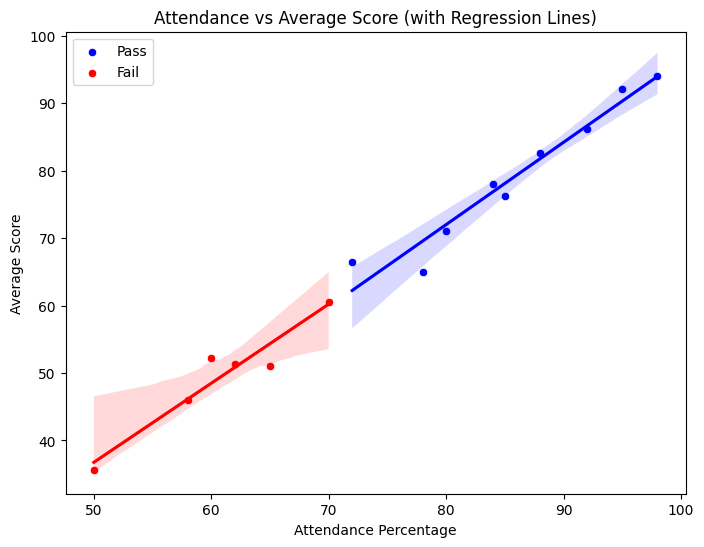

'\nSeaborn made the visualizations easier and more visually appealing with less code,\nespecially for statistical plots like bar charts and regression lines. Matplotlib\nrequired more manual styling, while Seaborn handled colours, smoothing, and layout\nautomatically. Overall, Seaborn felt faster and more convenient for these tasks.\n'

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("student_data.csv")

# Add avg_score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# ---------------------------------------------------------
# 1. SEABORN BAR PLOTS (Math & Science by Pass/Fail)
# ---------------------------------------------------------
plt.figure(figsize=(12,5))

# Subplot 1 — Math
ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math',hue='passed', ax=ax1, palette='Blues', legend=False)
ax1.set_title("Average Math Score by Pass/Fail")
ax1.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax1.set_ylabel("Average Math Score")

# Subplot 2 — Science
ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science', hue='passed', ax=ax2, palette='Greens', legend=False)
ax2.set_title("Average Science Score by Pass/Fail")
ax2.set_xlabel("Passed (0 = Fail, 1 = Pass)")
ax2.set_ylabel("Average Science Score")

plt.tight_layout()
plt.savefig("seaborn_barplots.png")
plt.show()

# ---------------------------------------------------------
# 2. SEABORN SCATTER + REGRESSION PLOT
# ---------------------------------------------------------
plt.figure(figsize=(8,6))

# Pass group
sns.scatterplot(
    data=df[df['passed']==1],
    x='attendance_pct', y='avg_score',
    color='blue', label='Pass'
)
sns.regplot(
    data=df[df['passed']==1],
    x='attendance_pct', y='avg_score',
    scatter=False, color='blue'
)

# Fail group
sns.scatterplot(
    data=df[df['passed']==0],
    x='attendance_pct', y='avg_score',
    color='red', label='Fail'
)
sns.regplot(
    data=df[df['passed']==0],
    x='attendance_pct', y='avg_score',
    scatter=False, color='red'
)

plt.title("Attendance vs Average Score (with Regression Lines)")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("seaborn_scatter_regression.png")
plt.show()

# ---------------------------------------------------------
# COMMENT: Seaborn vs Matplotlib (2–3 sentences)
# ---------------------------------------------------------
"""
Seaborn made the visualizations easier and more visually appealing with less code,
especially for statistical plots like bar charts and regression lines. Matplotlib
required more manual styling, while Seaborn handled colours, smoothing, and layout
automatically. Overall, Seaborn felt faster and more convenient for these tasks.
"""


Training Accuracy: 1.0
Test Accuracy: 1.0

=== Test Set Predictions ===
Jack: Actual=0, Predicted=0 --> ✅ Correct
Liam: Actual=0, Predicted=0 --> ✅ Correct
Alice: Actual=1, Predicted=1 --> ✅ Correct

=== Feature Importance (sorted) ===
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


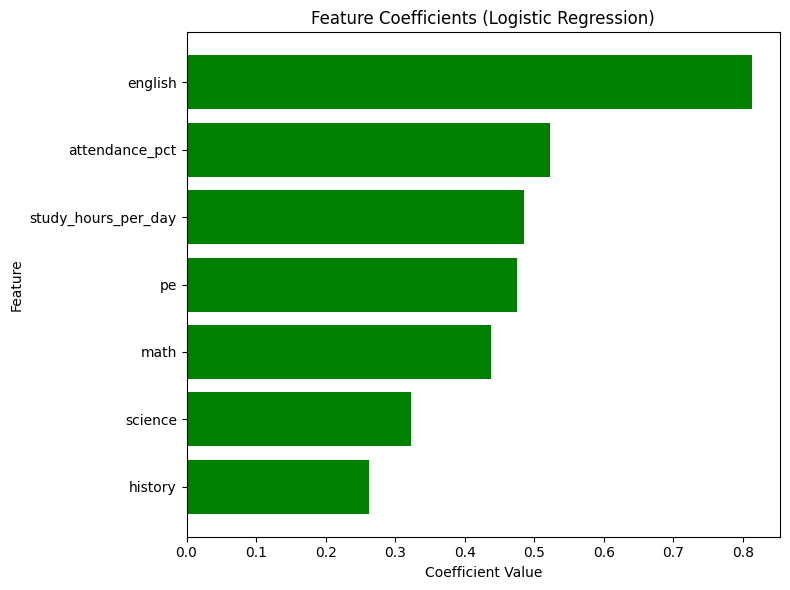


=== New Student Prediction ===
Prediction: Pass
Probabilities [Fail, Pass]: [0.09203526 0.90796474]


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# STEP 1 — PREPARE DATA
# ---------------------------------------------------------

df = pd.read_csv("student_data.csv")

# Features (exclude name)
feature_cols = ['math', 'science', 'english', 'history', 'pe',
                'attendance_pct', 'study_hours_per_day']

X = df[feature_cols]
y = df['passed']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------
# STEP 2 — TRAIN MODEL
# ---------------------------------------------------------

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_accuracy = model.score(X_train_scaled, y_train)
print("Training Accuracy:", train_accuracy)

# ---------------------------------------------------------
# STEP 3 — EVALUATE MODEL
# ---------------------------------------------------------

y_pred = model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_accuracy)

print("\n=== Test Set Predictions ===")
test_names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(test_names, y_test, y_pred):
    status = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name}: Actual={actual}, Predicted={pred} --> {status}")

# ---------------------------------------------------------
# STEP 4 — FEATURE IMPORTANCE (COEFFICIENTS)
# ---------------------------------------------------------

coefficients = model.coef_[0]
feature_importance = list(zip(feature_cols, coefficients))

# Sort by absolute value
feature_importance_sorted = sorted(
    feature_importance,
    key=lambda x: abs(x[1]),
    reverse=True
)

print("\n=== Feature Importance (sorted) ===")
for feature, coef in feature_importance_sorted:
    print(f"{feature}: {coef:.4f}")

# Plot coefficients
plt.figure(figsize=(8, 6))

features = [f for f, c in feature_importance_sorted]
coefs = [c for f, c in feature_importance_sorted]
colors = ['green' if c > 0 else 'red' for c in coefs]

plt.barh(features, coefs, color=colors)
plt.title("Feature Coefficients (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

# ---------------------------------------------------------
# STEP 5 — BONUS: PREDICT NEW STUDENT (FIXED)
# ---------------------------------------------------------

# Define new student as a DataFrame with the SAME feature names
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
new_student_df = pd.DataFrame(new_student, columns=feature_cols)

# Now transform using the same scaler (no error)
new_student_scaled = scaler.transform(new_student_df)

prediction = model.predict(new_student_scaled)[0]
probabilities = model.predict_proba(new_student_scaled)[0]

print("\n=== New Student Prediction ===")
print("Prediction:", "Pass" if prediction == 1 else "Fail")
print("Probabilities [Fail, Pass]:", probabilities)
